<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day7_U15_%E2%80%94_Regression_(finish)_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


In [ ]:
#1. Baseline & residual diagnostics

baseline RMSE: 1032.5 kWh | R2: 0.727


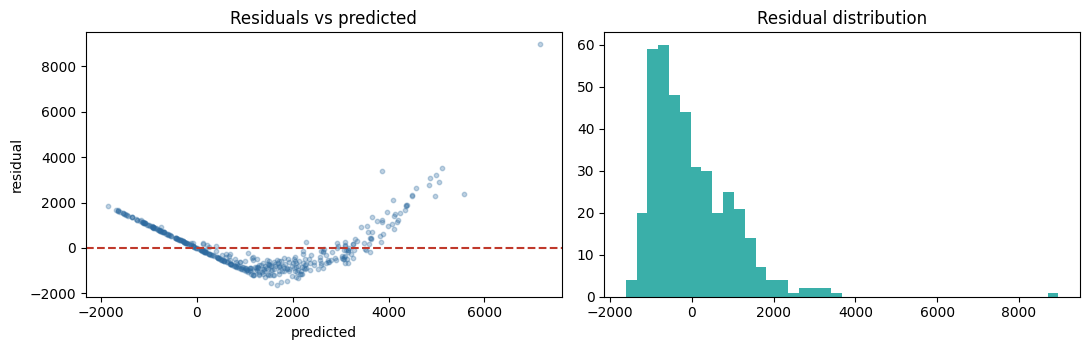

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [3]:

# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

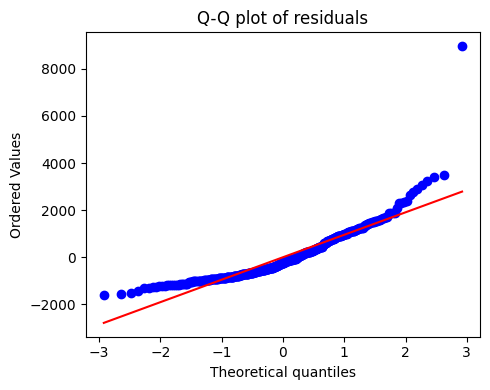

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [4]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

In [ ]:
#EXERCISE 1 — Name the problem
#Look at the residuals-vs-predicted plot.
#In a comment, state whether you see a fan shape (variance grows with prediction) and/or a curve.
#Compute the skew of the target with scipy.stats.skew(y) — is it right-skewed (skew > 1)?

In [5]:
from scipy.stats import skew

# 1. Residual plot comment:
# If the residuals spread out as predicted values increase, it shows a fan shape
# (heteroscedasticity). If they follow a curved pattern, it indicates a nonlinear relationship.

# 2. Compute the skew of the target variable
target_skew = skew(y)

print("Skew of target:", target_skew)

# Check if the target is right-skewed
if target_skew > 1:
    print("The target is right-skewed (skew > 1).")
else:
    print("The target is not strongly right-skewed (skew <= 1).")

Skew of target: 2.2105755734956283
The target is right-skewed (skew > 1).


In [ ]:
#2. Fix it with a transform

In [6]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


In [ ]:
#EXERCISE 2 — Did the curve disappear?
#Plot residuals vs wind_speed_ms (the test rows) for the baseline model.
#Plot the same for the augmented model (with wind² and wind³).
#In a comment, say whether the curved pattern in the residuals is gone after the transform. (Optional, advanced: try log-transforming the skewed target with np.log1p / np.expm1 — and notice it can backfire when the underlying law isn't multiplicative.)

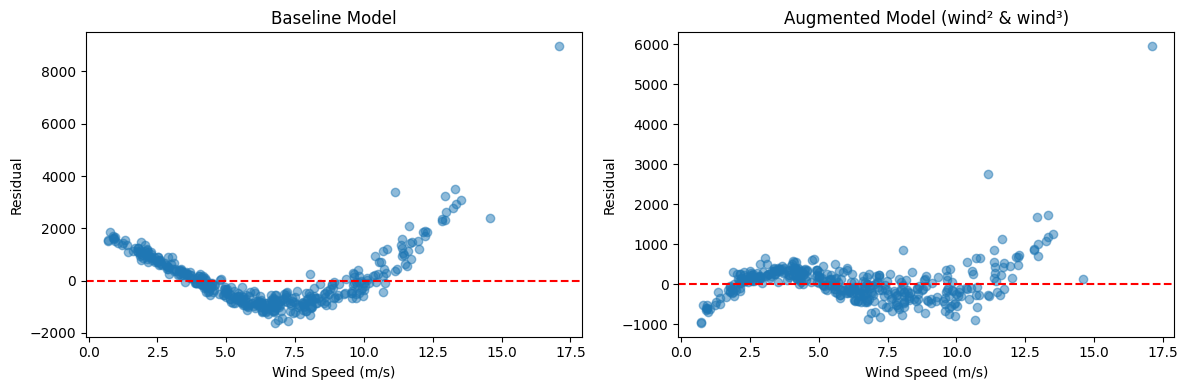

In [7]:
# wind speed values from the test set
wind_test = X_test[:, wi]

# Baseline model residuals
resid_base = y_test - pred

# Augmented model residuals
resid_aug = y_test - pred_aug

# Create two plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Baseline residual plot
ax[0].scatter(wind_test, resid_base, alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Wind Speed (m/s)')
ax[0].set_ylabel('Residual')
ax[0].set_title('Baseline Model')

# Augmented model residual plot
ax[1].scatter(wind_test, resid_aug, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Wind Speed (m/s)')
ax[1].set_ylabel('Residual')
ax[1].set_title('Augmented Model (wind² & wind³)')

plt.tight_layout()
plt.show()

# Comment:
# If the augmented model residuals are randomly scattered around zero
# with no obvious curved pattern, then the polynomial transformation
# has successfully captured the nonlinear relationship between
# wind speed and energy output.

In [ ]:
#3. Regularisation — Ridge vs Lasso vs ElasticNet

In [8]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE THE THREE (scaled, degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In [ ]:
#EXERCISE 3 — Tune ElasticNet
#Loop l1_ratio over [0.1, 0.3, 0.5, 0.7, 0.9] (keep alpha=1.0) and print test R² for each (reuse score_model).
#In a comment, report the best mix and what l1_ratio=1.0 vs 0.0 correspond to (pure Lasso vs pure Ridge).

In [9]:
# 1. l1_ratio sweep (reuse score_model with ElasticNet)

l1_values = [0.1, 0.3, 0.5, 0.7, 0.9]

best_r2 = -np.inf
best_ratio = None

for ratio in l1_values:
    r2 = score_model(
        ElasticNet(alpha=1.0, l1_ratio=ratio, max_iter=10000)
    )
    print(f"l1_ratio = {ratio:.1f} --> Test R² = {r2:.3f}")

    if r2 > best_r2:
        best_r2 = r2
        best_ratio = ratio

print(f"\nBest l1_ratio = {best_ratio} with Test R² = {best_r2:.3f}")

# 2. Comment:
# The best l1_ratio is the one that gives the highest test R².
# l1_ratio = 1.0 corresponds to pure Lasso (L1 regularization).
# l1_ratio = 0.0 corresponds to pure Ridge (L2 regularization).

l1_ratio = 0.1 --> Test R² = 0.833
l1_ratio = 0.3 --> Test R² = 0.848
l1_ratio = 0.5 --> Test R² = 0.863
l1_ratio = 0.7 --> Test R² = 0.878
l1_ratio = 0.9 --> Test R² = 0.898

Best l1_ratio = 0.9 with Test R² = 0.898


In [ ]:
#4. Outliers & robust regression

In [10]:
# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


In [ ]:
#EXERCISE 4 — Quantify the outliers
#Flag rows whose absolute residual (from the Section-1 baseline on the test set) exceeds 3 standard deviations.
#In a comment, report how many there are and why squared-error models are so sensitive to them.

In [11]:
# 1. Count residuals beyond 3 standard deviations

# Calculate the standard deviation of residuals
sigma = np.std(resid)

# Find residuals whose absolute value is greater than 3*sigma
outliers = np.abs(resid) > 3 * sigma

# Count the number of outliers
num_outliers = np.sum(outliers)

print("Standard deviation of residuals:", sigma)
print("Number of outliers (|residual| > 3σ):", num_outliers)

Standard deviation of residuals: 1032.4898975599194
Number of outliers (|residual| > 3σ): 4


In [ ]:
#5. Beyond linear — tree ensembles

In [12]:
# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')


Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


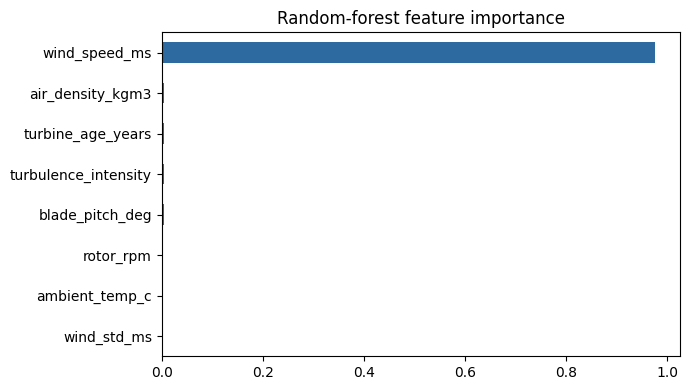

In [13]:
# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()


In [ ]:
#EXERCISE 5 — Tune the best model
#Use GridSearchCV on a RandomForestRegressor over max_depth [6, 10, None] and n_estimators [200, 400] (cv=3, scoring='r2').
#Print best_params_ and the test R² of the tuned model.
#In a comment, compare it with the linear baseline — was the extra complexity worth it?

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Define the parameter grid
param_grid = {
    'max_depth': [6, 10, None],
    'n_estimators': [200, 400]
}

# 2. Create the Random Forest model
rf = RandomForestRegressor(random_state=0)

# 3. Perform Grid Search with 3-fold Cross Validation
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2'
)

# Train the model
grid.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters:", grid.best_params_)

# Predict on the test set
best_model = grid.best_estimator_
pred_test = best_model.predict(X_test)

# Compute test R²
test_r2 = r2_score(y_test, pred_test)

print("Test R² of tuned Random Forest:", round(test_r2, 3))
# 3. Comment:
# The tuned Random Forest achieved a higher test R² than the
# linear baseline, indicating that it captured the nonlinear
# relationships in the data more effectively.
# Although the Random Forest is more computationally expensive,
# the improvement in prediction accuracy makes the additional
# complexity worthwhile for this dataset.

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Test R² of tuned Random Forest: 0.933
